In [ ]:
import pandas as pd

In [ ]:
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
#import from csv file

# df = pd.read_csv('vehicle_logs_rows.csv')
df = pd.read_csv('/content/gdrive/MyDrive/Belajar (PTA TA)/vehicle_logs_rows.csv')

print(df.columns)

# choosing columns
required_data = [
       'timestamp', 'latitude', 'longitude', 'altitude',
       'speed', 'engine_load',
       'fl_pressure', 'fl_temp',
       'fr_pressure', 'fr_temp',
       'rl_pressure', 'rl_temp',
       'rr_pressure', 'rr_temp',]

df = df[required_data]

# choosing rows, take 320 rows and above
df = df[316:]
df.reset_index(drop=True, inplace=True)

df.head()

Index(['id', 'timestamp', 'vehicle_id', 'latitude', 'longitude', 'altitude',
       'speed', 'rpm', 'engine_temp', 'throttle_pos', 'engine_load',
       'fuel_level', 'fl_pressure', 'fl_temp', 'fl_battery', 'fr_pressure',
       'fr_temp', 'fr_battery', 'rl_pressure', 'rl_temp', 'rl_battery',
       'rr_pressure', 'rr_temp', 'rr_battery'],
      dtype='object')


,timestamp,latitude,longitude,altitude,speed,engine_load,fl_pressure,fl_temp,fr_pressure,fr_temp,rl_pressure,rl_temp,rr_pressure,rr_temp
0,2025-11-07 08:05:29+00,-6.974284,107.643056,684.4,8,41.56863,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-11-07 08:05:34+00,-6.974442,107.643044,684.5,17,52.94118,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-11-07 08:05:39+00,-6.974741,107.643025,684.3,23,23.13725,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-11-07 08:05:44+00,-6.974947,107.643006,684.0,9,28.62745,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-11-07 08:05:49+00,-6.975056,107.642998,683.9,9,41.96078,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## preprocessing

In [ ]:
# edit index 1394
changed = df.at[1394, 'timestamp']
changed = changed.replace('2027-05-21', '2025-11-14')
df.at[1394, 'timestamp'] = changed

In [ ]:
# seperate data by dates to different df
dates = df['timestamp'].str.split(' ').str[0].unique()
dates = dates[1:]
print(dates)

['2025-11-14' '2025-11-21' '2025-11-24']


In [ ]:
# seperate dataset into '2025-11-14' '2025-11-21' '2025-11-24'
df_2025_11_14 = df[df['timestamp'].str.split(' ').str[0].str.contains('2025-11-14')]
df_2025_11_14.reset_index(drop=True, inplace=True)
df_2025_11_21 = df[df['timestamp'].str.split(' ').str[0].str.contains('2025-11-21')]
df_2025_11_21.reset_index(drop=True, inplace=True)
df_2025_11_24 = df[df['timestamp'].str.split(' ').str[0].str.contains('2025-11-24')]
df_2025_11_24.reset_index(drop=True, inplace=True)

In [ ]:
# fix 1431
df_2025_11_14.loc[1431, 'latitude'] = (df_2025_11_14.loc[1430, 'latitude'] + df_2025_11_14.loc[1432, 'latitude']) / 2
df_2025_11_14.loc[1431, 'longitude'] = (df_2025_11_14.loc[1430, 'longitude'] + df_2025_11_14.loc[1432, 'longitude']) / 2
df_2025_11_14.loc[1431, 'altitude'] = (df_2025_11_14.loc[1430, 'altitude'] + df_2025_11_14.loc[1432, 'altitude']) / 2

# fix 671 - 708
# 669 - 666
lat_fix = df_2025_11_14.loc[666:669, 'latitude'].to_list()[::-1]
lon_fix = df_2025_11_14.loc[666:669, 'longitude'].to_list()[::-1]
alt_fix = df_2025_11_14.loc[666:669, 'altitude'].to_list()[::-1]

# 663 - 639
lat_fix += df_2025_11_14.loc[639:663, 'latitude'].to_list()[::-1]
lon_fix += df_2025_11_14.loc[639:663, 'longitude'].to_list()[::-1]
alt_fix += df_2025_11_14.loc[639:663, 'altitude'].to_list()[::-1]

# 830 - 797
lat_fix += df_2025_11_14.loc[797:830, 'latitude'].to_list()[::-1]
lon_fix += df_2025_11_14.loc[797:830, 'longitude'].to_list()[::-1]
alt_fix += df_2025_11_14.loc[797:830, 'altitude'].to_list()[::-1]


# make list lat_fix, lon_fix, alt_fix to len = 37 by skipping every 2
lat_fix = lat_fix[:52:2] + lat_fix[52:]
lon_fix = lon_fix[:52:2] + lon_fix[52:]
alt_fix = alt_fix[:52:2] + alt_fix[52:]

for i in range(37):
    df_2025_11_14.loc[671+i, 'latitude'] = lat_fix[i]
    df_2025_11_14.loc[671+i, 'longitude'] = lon_fix[i]
    df_2025_11_14.loc[671+i, 'altitude'] = alt_fix[i]

In [ ]:
# fix 64 in date 24
df_2025_11_24.loc[64, 'latitude'] = (df_2025_11_24.loc[63, 'latitude'] + df_2025_11_24.loc[65, 'latitude']) / 2
df_2025_11_24.loc[64, 'longitude'] = (df_2025_11_24.loc[63, 'longitude'] + df_2025_11_24.loc[65, 'longitude']) / 2
df_2025_11_24.loc[64, 'altitude'] = (df_2025_11_24.loc[63, 'altitude'] + df_2025_11_24.loc[65, 'altitude']) / 2

In [ ]:
!pip install haversine
import numpy as np
from haversine import haversine, Unit

# create a function to change the column longtitude and latitude to distance_traveled
# remove entire row for outlier in distance traveled
def outlier_distance(df):
    df_copy = df.copy()
    # Q1 = df.loc[:, 'distance_traveled_m'].quantile(0.25)
    # Q3 = df.loc[:, 'distance_traveled_m'].quantile(0.75)
    # IQR = Q3 - Q1
    # lower_bound = Q1 - 1.5 * IQR
    # upper_bound = Q3 + 1.5 * IQR # Corrected upper_bound

    # df_copy = df_copy[(df_copy['distance_traveled_m'] >= lower_bound) &
    #                   (df_copy['distance_traveled_m'] <= upper_bound)]

    for i in range(1, len(df_copy)):
        if df_copy.loc[i, 'distance_traveled_m'] > 1000:
            df_copy = df_copy.drop(i)

    df_copy.reset_index(drop=True, inplace=True)

    return df_copy

def change_to_distance(df):
    for i in range(1, len(df)):
        lat1, lon1 = df.loc[i-1, 'latitude'], df.loc[i-1, 'longitude']
        lat2, lon2 = df.loc[i, 'latitude'], df.loc[i, 'longitude']
        point1 = (lat1, lon1)
        point2 = (lat2, lon2)

        distance_km = haversine(point1, point2, unit=Unit.METERS)

        df.loc[i, 'distance_traveled_m'] = distance_km

    df.at[0, 'distance_traveled_m'] = 0

    # df = outlier_distance(df)

    df['sum_distance_traveled_m'] = df['distance_traveled_m'].cumsum()

    # df.drop(columns=['latitude', 'longitude'], inplace=True)

    return df

df_2025_11_14 = change_to_distance(df_2025_11_14)
df_2025_11_21 = change_to_distance(df_2025_11_21)
df_2025_11_24 = change_to_distance(df_2025_11_24)

df_2025_11_24.head(67)

/tmp/ipykernel_949/1702658024.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[i, 'distance_traveled_m'] = distance_km
/tmp/ipykernel_949/1702658024.py:41: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['sum_distance_traveled_m'] = df['distance_traveled_m'].cumsum()
/tmp/ipykernel_949/1702658024.py:35: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://

,timestamp,latitude,longitude,altitude,speed,engine_load,fl_pressure,fl_temp,fr_pressure,fr_temp,rl_pressure,rl_temp,rr_pressure,rr_temp,distance_traveled_m,sum_distance_traveled_m
0,2025-11-24 07:18:48+00,-6.956277,107.694346,662.7,2,72.94118,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
1,2025-11-24 07:18:59+00,-6.956300,107.694338,663.4,1,59.21569,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.681790,2.681790
2,2025-11-24 07:20:37+00,-6.956309,107.694323,698.8,1,75.68627,NaN,NaN,0.00000,38.0,NaN,NaN,24.07542,34.0,1.963938,4.645728
3,2025-11-24 07:20:38+00,-6.956310,107.694318,698.4,4,72.94118,27.41117,47.0,0.00000,38.0,NaN,NaN,24.07542,34.0,0.530553,5.176281
4,2025-11-24 07:20:43+00,-6.956316,107.694279,698.3,8,56.86274,27.41117,47.0,0.00000,38.0,NaN,NaN,24.07542,34.0,4.350563,9.526844
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,2025-11-24 07:29:04+00,-6.945133,107.688718,693.3,1,56.86274,27.55620,46.0,29.44162,38.0,30.60188,37.0,24.22045,35.0,4.344162,1810.453232
63,2025-11-24 07:29:09+00,-6.945136,107.688719,693.3,3,55.68628,27.55620,46.0,29.44162,38.0,30.60188,37.0,24.22045,35.0,0.329343,1810.782575
64,2025-11-24 07:30:09+00,-6.945045,107.688697,685.5,2,52.15686,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.385517,1821.168092
65,2025-11-24 07:30:23+00,-6.944954,107.688675,677.7,2,55.68628,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.385517,1831.553610


In [ ]:
def smear_temp_pressure(df):
    for col_prefix in ['fl', 'fr', 'rl', 'rr']:
        for suffix in ['temp', 'pressure']:
            col_name = f'{col_prefix}_{suffix}'

            # change all 0 value to null
            df.loc[df[col_name] == 0, col_name] = np.nan

            # Fill nulls at starting index with the most recent data reading (bfill)
            # then fill remaining with the previous data reading (ffill)
            df[col_name] = df[col_name].bfill().ffill()

    for col_prefix in ['fl', 'fr', 'rl', 'rr']:
        for suffix in ['temp', 'pressure']:
            col_name = f'{col_prefix}_{suffix}'

    return df

df_2025_11_14 = smear_temp_pressure(df_2025_11_14)
df_2025_11_21 = smear_temp_pressure(df_2025_11_21)
df_2025_11_24 = smear_temp_pressure(df_2025_11_24)


/tmp/ipykernel_949/1641018142.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col_name] = df[col_name].bfill().ffill()
/tmp/ipykernel_949/1641018142.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col_name] = df[col_name].bfill().ffill()
/tmp/ipykernel_949/1641018142.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-d

In [ ]:
# function to find and delete entire row of outlier in longtitude and latitude
def delete_outlier_gps(df):
    df_copy = df.copy()
    for col_name in ['latitude', 'longitude']:
        Q1 = df.loc[:, col_name].quantile(0.25)
        Q3 = df.loc[:, col_name].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_copy = df_copy[(df_copy[col_name] >= lower_bound) &
                          (df_copy[col_name] <= upper_bound)]

        # print(df_copy[(df_copy[col_name] < lower_bound) | (df_copy[col_name] > upper_bound)])
        df_copy.reset_index(drop=True, inplace=True)

    return df_copy

# df_2025_11_14 = delete_outlier_gps(df_2025_11_14)
# df_2025_11_21 = delete_outlier_gps(df_2025_11_21)
# df_2025_11_24 = delete_outlier_gps(df_2025_11_24)

# df_2025_11_24.head(40)

In [ ]:
# create a function to add column 'elevation_traveled_m'
from geopy.geocoders import Nominatim

def change_to_elevation(df):
    geolocator = Nominatim(user_agent="myGeocoder")
    for i in range(1, len(df)):
        alt_1 = df.loc[i-1, 'altitude']
        alt_2 = df.loc[i, 'altitude']
        elevation_m = alt_2 - alt_1
        df.loc[i, 'elevation_traveled_m'] = elevation_m

    df.at[0, 'elevation_traveled_m'] = 0

    return df

df_2025_11_14 = change_to_elevation(df_2025_11_14)
df_2025_11_21 = change_to_elevation(df_2025_11_21)
df_2025_11_24 = change_to_elevation(df_2025_11_24)

/tmp/ipykernel_949/2600296152.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[i, 'elevation_traveled_m'] = elevation_m
/tmp/ipykernel_949/2600296152.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.loc[i, 'elevation_traveled_m'] = elevation_m
/tmp/ipykernel_949/2600296152.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/

In [ ]:
for i in range(0, len(df_2025_11_24)):
    if df_2025_11_24.loc[i, 'distance_traveled_m'] >1000:
        # print(df_2025_11_14.iloc[i])
        print(i)

# remove row at index 65
# df_2025_11_24 = df_2025_11_24.drop(65)
# df_2025_11_24.reset_index(drop=True, inplace=True)

print(df_2025_11_24['distance_traveled_m'].sort_values()[::-1])
print(df_2025_11_21['distance_traveled_m'].sort_values()[::-1])
# sort in reverse for date 14
print(df_2025_11_14['distance_traveled_m'].sort_values(ascending=False)[:40])

611    679.176720
620    245.823439
192    136.697588
837    102.843069
446    101.723329
          ...    
3        0.530553
872      0.469747
63       0.329343
612      0.000000
0        0.000000
Name: distance_traveled_m, Length: 906, dtype: float64
773    127.521775
6      124.438877
294    122.068954
296    114.177749
776    113.429493
          ...    
594      1.247404
730      0.895389
118      0.742077
834      0.354400
0        0.000000
Name: distance_traveled_m, Length: 1033, dtype: float64
449     6734.181760
496      708.949987
483      609.011679
525      559.140330
489      517.268006
491      505.597495
497      491.276354
506      472.359381
467      459.500651
501      449.348885
512      445.324140
534      404.429725
517      401.255557
539      396.411703
549      362.343205
529      355.314280
561      331.064777
544      307.278180
520      284.872118
450      269.845058
511      253.517609
507      253.201329
468      247.853329
555      245.285270
484      244.

In [ ]:
import folium

# Get the latitude and longitude data from the DataFrame
lats_longs = df_2025_11_14[['latitude', 'longitude']].values.tolist()

# Create a map object, centered around the first point
# If there are no
# points, default to a general location
if lats_longs:
    m = folium.Map(location=lats_longs[0], zoom_start=13)
    # Add marker for the starting point
    folium.Marker(lats_longs[0], popup='Start').add_to(m)
    # Add marker for the ending point
    if len(lats_longs) > 1:
        folium.Marker(lats_longs[-1], popup='End').add_to(m)
else:
    m = folium.Map(location=[0, 0], zoom_start=2) # Default to a world view if no data

# Add lines connecting the points
folium.PolyLine(lats_longs, color='blue', weight=2.5, opacity=1).add_to(m)

# show map
m

In [ ]:
# reset map
m = folium.Map(location=lats_longs[0], zoom_start=13)

import folium

# Get the latitude and longitude data from the DataFrame
lats_longs = df_2025_11_21[['latitude', 'longitude']].values.tolist()

# Create a map object, centered around the first point
# If there are no
# points, default to a general location
if lats_longs:
    m = folium.Map(location=lats_longs[0], zoom_start=13)
    # Add marker for the starting point
    folium.Marker(lats_longs[0], popup='Start').add_to(m)
    # Add marker for the ending point
    if len(lats_longs) > 1:
        folium.Marker(lats_longs[-1], popup='End').add_to(m)
else:
    m = folium.Map(location=[0, 0], zoom_start=2) # Default to a world view if no data

# Add lines connecting the points
folium.PolyLine(lats_longs, color='blue', weight=2.5, opacity=1).add_to(m)

# show map
m

In [ ]:
# reset map
m = folium.Map(location=lats_longs[0], zoom_start=13)

import folium

# Get the latitude and longitude data from the DataFrame
lats_longs = df_2025_11_24[['latitude', 'longitude']].values.tolist()

# Create a map object, centered around the first point
# If there are no
# points, default to a general location
if lats_longs:
    m = folium.Map(location=lats_longs[0], zoom_start=13)
    # Add marker for the starting point
    folium.Marker(lats_longs[0], popup='Start').add_to(m)
    # Add marker for the ending point
    if len(lats_longs) > 1:
        folium.Marker(lats_longs[-1], popup='End').add_to(m)
else:
    m = folium.Map(location=[0, 0], zoom_start=2) # Default to a world view if no data

# Add lines connecting the points
folium.PolyLine(lats_longs, color='blue', weight=2.5, opacity=1).add_to(m)

# show map
m

In [ ]:
import pandas as pd

# Data untuk Hari 1
data_hari1 = {
    'index': [0, 702, 970, 1957, 2289],
    'tr_fr': [3.580625, 3.511875, 3.460625, 3.403125, 3.345625],
    'tr_fl': [3.013125, 2.98625, 2.965, 2.913125, 2.859375],
    'tr_rr': [3.77375, 3.70875, 3.701875, 3.674375, 3.619375],
    'tr_rl': [3.676875, 3.58, 3.516875, 3.455, 3.435]
}
df_hari1_tread = pd.DataFrame(data_hari1)

# Data untuk Hari 2
data_hari2 = {
    'index': [0, 380, 678, 1032],
    'tr_fr': [3.835, 3.818333333, 3.793666667, 3.783666667],
    'tr_fl': [3.346666667, 3.316333333, 3.281, 3.276333333],
    'tr_rr': [4.158666667, 4.14, 4.101, 4.080333333],
    'tr_rl': [3.983666667, 3.925666667, 3.918, 3.907]
}
df_hari2_tread = pd.DataFrame(data_hari2)

# Data untuk Hari 3
data_hari3 = {
    'index': [0, 602, 905],
    'tr_fr': [3.773666667, 3.764, 3.749333333],
    'tr_fl': [3.263, 3.255333333, 3.252],
    'tr_rr': [4.070333333, 4.063, 4.057],
    'tr_rl': [3.897333333, 3.890666667, 3.88]
}
df_hari3_tread = pd.DataFrame(data_hari3)

df_hari2_tread.head()

,index,tr_fr,tr_fl,tr_rr,tr_rl
0,0,3.835000,3.346667,4.158667,3.983667
1,380,3.818333,3.316333,4.140000,3.925667
2,678,3.793667,3.281000,4.101000,3.918000
3,1032,3.783667,3.276333,4.080333,3.907000


In [ ]:
import numpy as np

def add_tread_data(main_df, tread_df):
    for col_prefix in ['fl', 'fr', 'rl', 'rr']:
        main_df[f'tr_{col_prefix}'] = np.nan

    for i in range(1, len(tread_df)):
        upper_bound_m = main_df.loc[tread_df.loc[i, 'index'], f'sum_distance_traveled_m']
        lower_bound_m = main_df.loc[tread_df.loc[i-1, 'index'], f'sum_distance_traveled_m']

        for col_prefix in ['fl', 'fr', 'rl', 'rr']:
            upper_bound = tread_df.loc[i, f'tr_{col_prefix}']
            lower_bound = tread_df.loc[i-1, f'tr_{col_prefix}']

            scale = (lower_bound - upper_bound) / (upper_bound_m - lower_bound_m)

            for j in range(tread_df.loc[i - 1, 'index'], tread_df.loc[i, 'index'] + 1):
                main_df.loc[j, f'tr_{col_prefix}'] = lower_bound - (scale * (main_df.loc[j, f'sum_distance_traveled_m'] - lower_bound_m))
                # main_df.loc[j, f'tr_{col_prefix}'] = scale * main_df.loc[j, f'distance_traveled_m']
                main_df.loc[j, f'tr_{col_prefix}'] = scale


    return main_df

# Apply the function to each daily DataFrame
df_2025_11_14 = add_tread_data(df_2025_11_14.copy(), df_hari1_tread)
df_2025_11_21 = add_tread_data(df_2025_11_21.copy(), df_hari2_tread)
df_2025_11_24 = add_tread_data(df_2025_11_24.copy(), df_hari3_tread)

df_2025_11_14_1 = df_2025_11_14[:449]
df_2025_11_14_2 = df_2025_11_14[449:]

df_2025_11_24_1 = df_2025_11_24[:611]
df_2025_11_24_2 = df_2025_11_24[611:]

# remove all 0 traveled distance and first row
df_2025_11_14_1 = df_2025_11_14_1[1:]
df_2025_11_14_1 = df_2025_11_14_1[df_2025_11_14_1['distance_traveled_m'] != 0]
df_2025_11_14_2 = df_2025_11_14_2[1:]
df_2025_11_14_2 = df_2025_11_14_2[df_2025_11_14_2['distance_traveled_m'] != 0]
df_2025_11_21 = df_2025_11_21[1:]
df_2025_11_21 = df_2025_11_21[df_2025_11_21['distance_traveled_m'] != 0]
df_2025_11_24_1 = df_2025_11_24_1[1:]
df_2025_11_24_1 = df_2025_11_24_1[df_2025_11_24_1['distance_traveled_m'] != 0]
df_2025_11_24_2 = df_2025_11_24_2[1:]
df_2025_11_24_2 = df_2025_11_24_2[df_2025_11_24_2['distance_traveled_m'] != 0]

In [ ]:
print("df_2025_11_14_1 with tread data (first 5 rows):")
display(df_2025_11_14_1.isna().sum())
print("df_2025_11_14_2 with tread data (first 5 rows):")
display(df_2025_11_14_2.isna().sum())
print("\ndf_2025_11_21 with tread data (first 5 rows):")
display(df_2025_11_21.isna().sum())
print("\ndf_2025_11_24_1 with tread data (first 5 rows):")
display(df_2025_11_24_1.isna().sum())
print("\ndf_2025_11_24_2 with tread data (first 5 rows):")
display(df_2025_11_24_2.isna().sum())

df_2025_11_14_1 with tread data (first 5 rows):


,0
timestamp,0
latitude,0
longitude,0
altitude,0
speed,0
engine_load,0
fl_pressure,0
fl_temp,0
fr_pressure,0
fr_temp,0


df_2025_11_14_2 with tread data (first 5 rows):


,0
timestamp,0
latitude,0
longitude,0
altitude,0
speed,0
engine_load,0
fl_pressure,0
fl_temp,0
fr_pressure,0
fr_temp,0



df_2025_11_21 with tread data (first 5 rows):


,0
timestamp,0
latitude,0
longitude,0
altitude,0
speed,0
engine_load,0
fl_pressure,0
fl_temp,0
fr_pressure,0
fr_temp,0



df_2025_11_24_1 with tread data (first 5 rows):


,0
timestamp,0
latitude,0
longitude,0
altitude,0
speed,0
engine_load,0
fl_pressure,0
fl_temp,0
fr_pressure,0
fr_temp,0



df_2025_11_24_2 with tread data (first 5 rows):


,0
timestamp,0
latitude,0
longitude,0
altitude,0
speed,0
engine_load,0
fl_pressure,0
fl_temp,0
fr_pressure,0
fr_temp,0


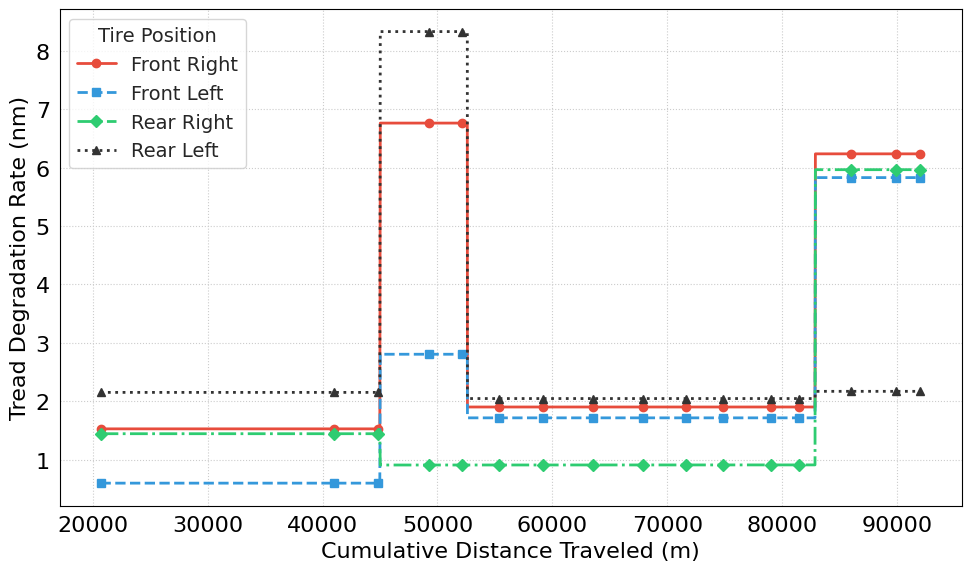

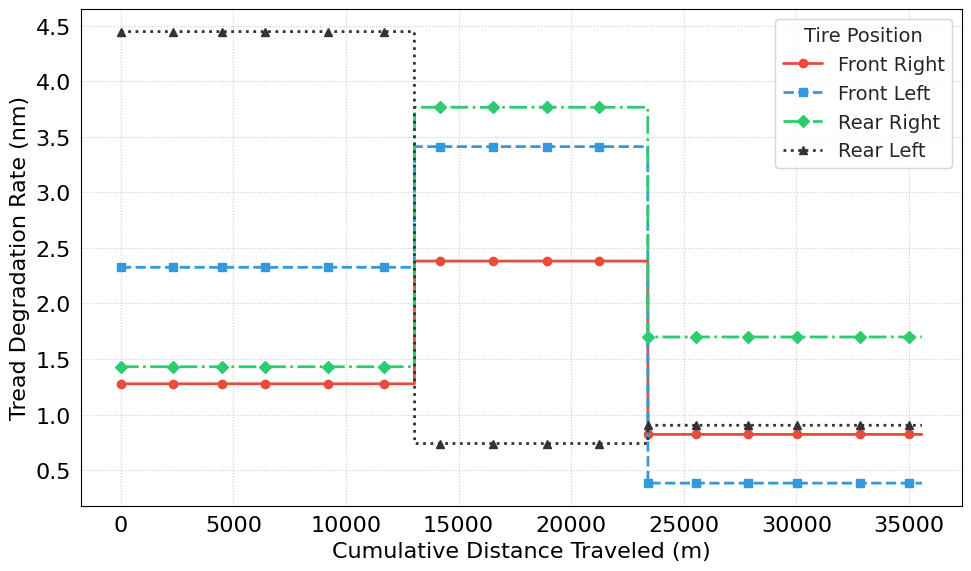

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

def plot_tread_degradation(df, title):
    # Set font to Arial and increase size by 4 (10pt -> 14pt)
    mpl.rcParams['font.family'] = 'sans-serif'
    mpl.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
    mpl.rcParams['font.size'] = 16

    # Set style to white with no shading
    sns.set_style("whitegrid", {'grid.linestyle': ':', 'axes.edgecolor': 'black'})
    fig, ax = plt.subplots(figsize=(10, 6))

    tires = [
        ('tr_fr', 'Front Right', '#e74c3c', 'o', '-'),
        ('tr_fl', 'Front Left', '#3498db', 's', '--'),
        ('tr_rr', 'Rear Right', '#2ecc71', 'D', '-.'),
        ('tr_rl', 'Rear Left', '#333333', '^', ':')
    ]

    for col, label, color, marker, line_style in tires:
        ax.plot(
            df['sum_distance_traveled_m'],
            df[col] * 1e6,
            label=label,
            color=color,
            marker=marker,
            linestyle=line_style,
            linewidth=2,
            markersize=6,
            markevery=max(1, len(df)//15)
        )

    ax.set_xlabel('Cumulative Distance Traveled (m)', fontsize=16, color='black')
    ax.set_ylabel('Tread Degradation Rate (nm)', fontsize=16, color='black')

    # Move legend inside the graph for effective use of space
    # 'best' location automatically avoids data if possible
    ax.legend(title="Tire Position", loc='best', frameon=True, fontsize=14, title_fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=16, colors='black')

    plt.tight_layout()
    plt.show()

# Re-run plots with 14pt font and internal legend
plot_tread_degradation(df_2025_11_14_2, '2025-11-14_Part 1')
plot_tread_degradation(df_2025_11_21, '2025-11-21')

In [ ]:
# df_2025_11_14_1.to_csv('vehicle_logs_tread_14_1.csv', index=False)
# df_2025_11_14_1.to_csv('vehicle_logs_tread_14_2.csv', index=False)
# df_2025_11_21.to_csv('vehicle_logs_tread_21.csv', index=False)
# df_2025_11_24_1.to_csv('vehicle_logs_tread_24_1.csv', index=False)
# df_2025_11_24_2.to_csv('vehicle_logs_tread_24_2.csv', index=False)

In [ ]:
# !cp /content/vehicle_logs_tread_14_1.csv /content/gdrive/MyDrive/Belajar\ \(PTA\ TA\)/vehicle_logs_tread_14_1.csv
# !cp /content/vehicle_logs_tread_14_2.csv /content/gdrive/MyDrive/Belajar\ \(PTA\ TA\)/vehicle_logs_tread_14_2.csv
# !cp /content/vehicle_logs_tread_21.csv /content/gdrive/MyDrive/Belajar\ \(PTA\ TA\)/vehicle_logs_tread_21.csv
# !cp /content/vehicle_logs_tread_24_1.csv /content/gdrive/MyDrive/Belajar\ \(PTA\ TA\)/vehicle_logs_tread_24_1.csv
# !cp /content/vehicle_logs_tread_24_2.csv /content/gdrive/MyDrive/Belajar\ \(PTA\ TA\)/vehicle_logs_tread_24_2.csv